# ASTR 457: Foundations of Data Science in Astronomy

**Fall 2026, University of Illinois Urbana-Champaign**

Prof. Gautham Narayan | TA: Abha Vishwakarma

Tue Sep 1 / Thu Sep 3, 2026 - Day 3: recap, robust statistics, hypothesis testing (on Zoom both days)

<img src="images/uiuc_logo.png" alt="University of Illinois Urbana-Champaign wordmark" width="220" style="display:block;margin:0 auto;">


## Today's plan

We pick up exactly where we stopped on Day 2, with the median.

Then we go after the fit itself. We'll do k-sigma clipping, a way to estimate sigma from the data when we don't trust the one we were handed, the mixture model from Hogg, Bovy & Lang (2010), and a couple of other robust estimators worth knowing about.

After that, the bootstrap, which gets us an error bar on a number that has no formula for one.

Then hypothesis testing on real SDSS data. Is a difference we can see actually there, or is it noise?

One question runs through all of it, same as Day 2. How do we verify that our data, our fit, and our test are telling us the truth?


## Section 1: Where we left off on Day 2

## What we covered on Day 2

* GitHub mechanics: fork, work in your own folder under `submissions/netid/`, and the pull request is what actually turns the lab in
    * slow going, and it should have been. Most of you have only ever used Canvas or Moodle
* Probability: the axioms, Bayes' rule, and the base rate
    * a classifier that catches 90% of the real transients and flags only 20% of the junk still leaves us under 50% sure any given flag is real
    * Gauri's actual DECam base rate of about 1% makes it worse
* The central limit theorem, and where it stops working
    * the mean of almost anything goes Gaussian eventually
    * unless the distribution has infinite variance, like the Cauchy, in which case averaging more data buys us nothing


## Where we left off

The median survives the exact case that breaks the mean.

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**That is what robust means: an estimator that a handful of wild points can't drag around.**

</div> Let's watch it once more, and then push the same idea from averaging into fitting.


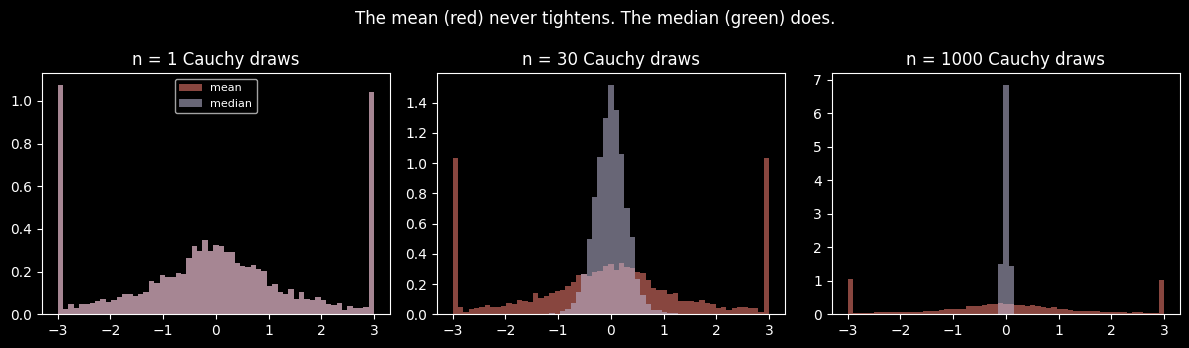

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(20260827)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, n_draws in zip(axes, [1, 30, 1000]):
    draws = rng.standard_cauchy(size=(5000, n_draws))
    means_c   = np.clip(draws.mean(axis=1),   -3, 3)
    medians_c = np.clip(np.median(draws, axis=1), -3, 3)
    bins = np.linspace(-3, 3, 60)
    ax.hist(means_c,   bins=bins, density=True, alpha=0.55, color='C3', label='mean')
    ax.hist(medians_c, bins=bins, density=True, alpha=0.55, color='C2', label='median')
    ax.set_title(f'n = {n_draws} Cauchy draws')
    if n_draws == 1:
        ax.legend(fontsize=8)
plt.suptitle('The mean (red) never tightens. The median (green) does.')
plt.tight_layout()
plt.show()


## Diagnostic: the QQ-plot

Plot your data's quantiles against a reference distribution's quantiles.

- points falling on a straight line → your data is well-described by the
  reference distribution (scipy draws a fitted reference line, not literally 45°)
- points that peel away (usually in the tails) tell you *where* the assumption
  breaks

This is the fast visual check for "am I allowed to assume Gaussian here?" It's the
same question underneath every least-squares fit you'll do this semester.

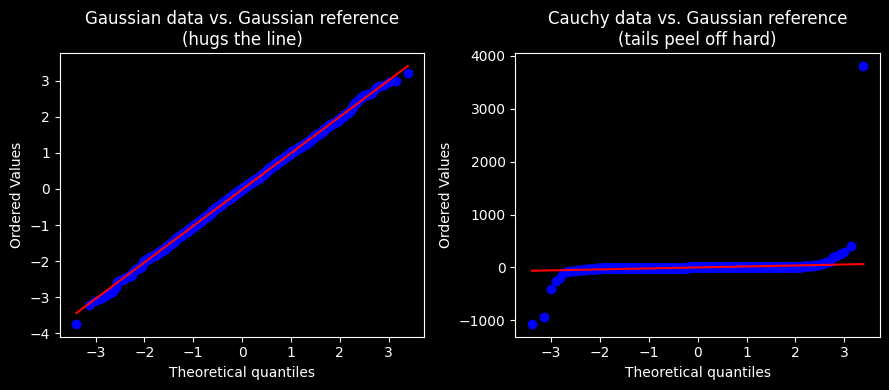

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
stats.probplot(rng.standard_normal(2000), dist='norm', plot=axes[0])
axes[0].set_title('Gaussian data vs. Gaussian reference\n(hugs the line)')
stats.probplot(rng.standard_cauchy(2000), dist='norm', plot=axes[1])
axes[1].set_title('Cauchy data vs. Gaussian reference\n(tails peel off hard)')
plt.tight_layout()
plt.show()

## Section 2: Robust statistics

## What least-squares actually assumes

Least-squares fitting makes three assumptions - our $y$ uncertainties are Gaussian, that the $x$ values are essentially exact, and every point's error is independent of every other point's.

Astronomical data routinely violates all three.

So this section is about what breaks, and about two standard fixes. K-sigma clipping is what Lab 01 Part 2 has you implement. The mixture model is what Part 3 grades you on understanding, and we're going to actually build that one rather than just describe it.

*Adapted from LSSTC-DSFP Session 7 Day0 "The Assumptions of Least Squares" (public, CC-licensed teaching material), reworked here as a live-taught demo rather than a fill-in-the-blank problem set.*


## A small dataset with a big problem

Twenty radial-velocity measurements of one star, taken across a ten-night observing run, each with a stated uncertainty.

The star is being tugged by an unseen companion, exactly the Day 1 setup. The orbit is long, so over this short a window the drift is a straight line.

A few of the exposures are contaminated. The wrong star drifted into the fiber, or scattered moonlight, or a cosmic ray on the trace. We don't know which ones.


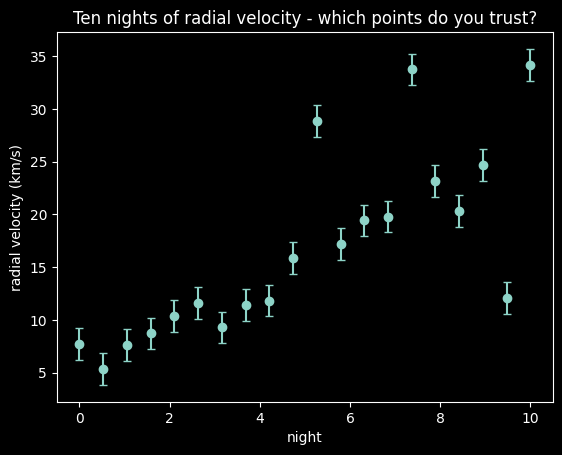

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260827)

n = 20
x_true = np.linspace(0, 10, n)
y_true = 2.0 * x_true + 5.0
sigma = np.full(n, 1.5)
y = y_true + rng.normal(0, sigma)

# contaminate 4 points with a much larger, non-Gaussian excursion
bad = rng.choice(n, size=4, replace=False)
y[bad] += rng.choice([-1, 1], size=4) * rng.uniform(8, 15, size=4)

plt.errorbar(x_true, y, yerr=sigma, fmt='o', capsize=3)
plt.xlabel('night'); plt.ylabel('radial velocity (km/s)')
plt.title('Ten nights of radial velocity - which points do you trust?')
plt.show()

Just by eye, which points look wrong? Write down the ones you would throw out, before we run any code.


## The reduced chi-squared statistic

$$\chi^2_{\rm red} = \frac{1}{n - k}\sum_i \frac{(y_i - \mathrm{model}(x_i))^2}{\sigma_i^2}$$

$n$ is the number of points and $k$ the number of fitted parameters. If the model is right and the $\sigma_i$ are honest, this lands near 1. Much bigger than 1 means the model is wrong, or the uncertainties are underestimated, or both.

How close to 1 counts as close? When everything is right, $\chi^2_{\rm red}$ still scatters by about $\sqrt{2/(n-k)}$, which is roughly $\pm 0.33$ for 20 points and 2 parameters. So 1.03 is unremarkable and 14 is a catastrophe.


## Fit 1: weighted least squares, everything included

This is what `np.polyfit`, or an AI assistant's first pass, hands us if we don't say anything about outliers. We pass the stated `sigma`, so it is a weighted fit.


naive fit: slope=2.15, intercept=5.91, chi2_red=14.27  (true slope=2.00, intercept=5.00)


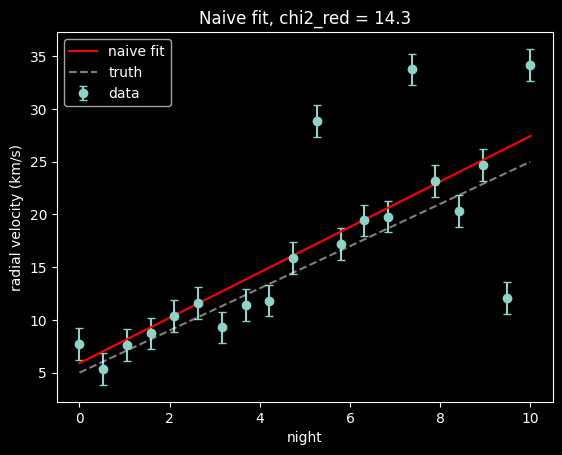

In [4]:
p_naive = np.polyfit(x_true, y, 1, w=1/sigma)
resid = y - np.polyval(p_naive, x_true)
chi2 = np.sum((resid / sigma) ** 2)
chi2_red = chi2 / (n - 2)
print(f"naive fit: slope={p_naive[0]:.2f}, intercept={p_naive[1]:.2f}, "
      f"chi2_red={chi2_red:.2f}  (true slope=2.00, intercept=5.00)")

xx = np.linspace(0, 10, 200)
plt.errorbar(x_true, y, yerr=sigma, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', label='naive fit')
plt.plot(xx, 2.0 * xx + 5.0, 'w--', alpha=0.5, label='truth')
plt.xlabel('night'); plt.ylabel('radial velocity (km/s)'); plt.legend()
plt.title(f'Naive fit, chi2_red = {chi2_red:.1f}')
plt.show()

## The same lesson, in the actual cited paper

<img src="images/hogg2010_fig2_naive_fit.png" alt="Hogg Bovy Lang 2010 Figure 2: naive weighted least-squares fit dragged off by outliers" width="760" style="display:block;margin:0 auto;">

<small>Figure 2 from Hogg, Bovy &amp; Lang (2010), arXiv:1008.4686, their own real 20-point example dataset (Table 1 in the paper). Same phenomenon: the naive weighted least-squares fit is visibly dragged off by a handful of outliers. This is the actual paper Lab 01 points you to.</small>


The $\chi^2_{\rm red}$ is way above 1, which is the same warning sign we got from the Day 1 demo.

The contaminated points are dragging both the slope and the intercept away from truth. They're dragging our uncertainty estimate too: a least-squares fit reports smaller error bars than it should, because it has no idea four of its inputs are lying to it.


## Fit 2: k-sigma clipping

Fit once, throw out anything more than $k\sigma$ away from the fit, then refit. Iterate until nothing new gets clipped.

This is what Lab 01 Part 2 asks you to implement.


## The k-sigma clipping criterion

Keep point $i$ only if

$$\left|\frac{y_i - \mathrm{model}(x_i)}{\sigma_i}\right| < k$$

We choose $k$ - the data does not derive it for us, and that choice is the method's weak point.


3-sigma clip: slope=2.04, intercept=5.37, chi2_red=1.03, clipped 4 of 20 points
actually-contaminated indices: [10, 14, 18, 19]; clipped indices: [10, 14, 18, 19]


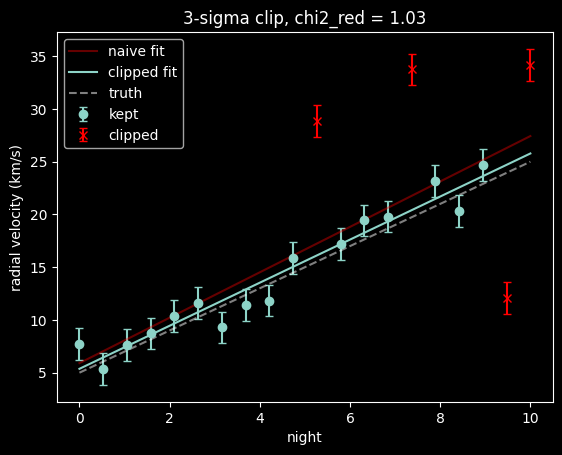

In [21]:
def sigma_clip_fit(x, y, sigma, k=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask])
        resid = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask

p_clip, mask = sigma_clip_fit(x_true, y, sigma, k=3.0)
resid = y[mask] - np.polyval(p_clip, x_true[mask])
chi2_red_clip = np.sum((resid / sigma[mask]) ** 2) / (mask.sum() - 2)
print(f"3-sigma clip: slope={p_clip[0]:.2f}, intercept={p_clip[1]:.2f}, "
      f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {n} points")
print(f"actually-contaminated indices: {sorted(bad)}; clipped indices: {sorted(np.where(~mask)[0])}")

plt.errorbar(x_true[mask], y[mask], yerr=sigma[mask], fmt='o', capsize=3, color='C0', label='kept')
plt.errorbar(x_true[~mask], y[~mask], yerr=sigma[~mask], fmt='x', capsize=3, color='r', label='clipped')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', alpha=0.4, label='naive fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0-', label='clipped fit')
plt.plot(xx, 2.0 * xx + 5.0, 'w--', alpha=0.5, label='truth')
plt.xlabel('night'); plt.ylabel('radial velocity (km/s)'); plt.legend()
plt.title(f'3-sigma clip, chi2_red = {chi2_red_clip:.2f}')
plt.show()

The threshold is $k$ measured in units of our stated $\sigma$. So there are two ways to get it wrong, and they turn out to be the same failure. We can pick a bad $k$, or we can feed it a wrong $\sigma$.

We'll look at both. First a wrong $\sigma$, over the next two slides, and then a live slider where you pick $k$ yourself.


## When our stated uncertainties are themselves wrong

If $\sigma$ is underestimated, clipping throws away good data. Points that are honestly a bit noisy start looking like outliers.

If $\sigma$ is overestimated, clipping keeps the bad data, because genuine contaminants no longer look discrepant enough to clip.

The trap is that from the fit alone both regimes can look clean, with a perfectly respectable $\chi^2_{\rm red}$, and we cannot tell which one we're in without independent knowledge of our uncertainties.

Watch the right panel on the next slide. It lands on $\chi^2_{\rm red} = 0.98$ with 3 of the 4 real contaminants still in the kept sample. <div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**A good-looking $\chi^2_{\rm red}$ certifies nothing.**

</div>


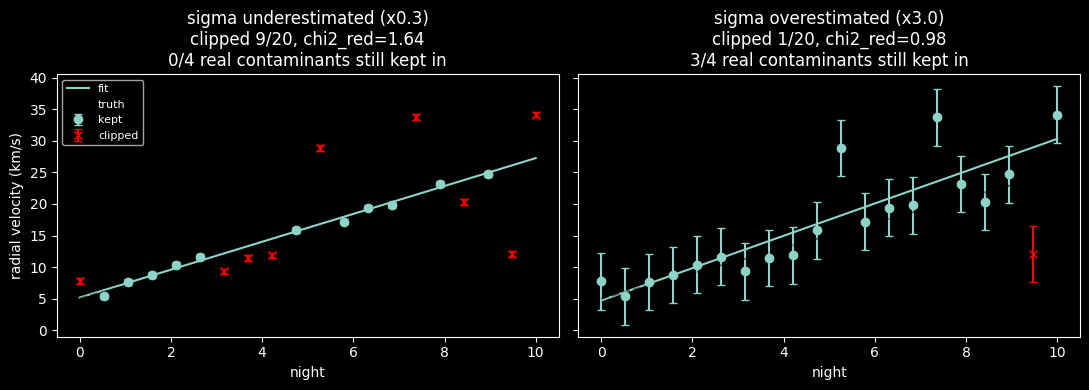

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, factor, label in zip(axes, [0.3, 3.0], ['sigma underestimated (x0.3)', 'sigma overestimated (x3.0)']):
    sigma_wrong = sigma * factor
    p_w, mask_w = sigma_clip_fit(x_true, y, sigma_wrong, k=3.0)
    r_w = y[mask_w] - np.polyval(p_w, x_true[mask_w])
    cr_w = np.sum((r_w / sigma_wrong[mask_w]) ** 2) / (mask_w.sum() - 2)
    n_bad_kept = len(set(np.where(mask_w)[0]) & set(bad))

    ax.errorbar(x_true[mask_w], y[mask_w], yerr=sigma_wrong[mask_w], fmt='o', capsize=3, color='C0', label='kept')
    ax.errorbar(x_true[~mask_w], y[~mask_w], yerr=sigma_wrong[~mask_w], fmt='x', capsize=3, color='r', label='clipped')
    ax.plot(xx, np.polyval(p_w, xx), 'C0-', label='fit')
    ax.plot(xx, 2.0 * xx + 5.0, 'k--', alpha=0.5, label='truth')
    ax.set_title(f'{label}\nclipped {(~mask_w).sum()}/{n}, chi2_red={cr_w:.2f}\n{n_bad_kept}/4 real contaminants still kept in')
    ax.set_xlabel('night')
axes[0].set_ylabel('radial velocity (km/s)'); axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Robust scale: the median absolute deviation (MAD)

Everything we just did assumed the stated $\sigma$ was right. When we don't trust it, we can measure one from the data instead - that is what **MAD** is for.

$$\mathrm{MAD} = \mathrm{median}\big(|r_i - \mathrm{median}(r)|\big), \qquad \hat\sigma \approx 1.4826 \times \mathrm{MAD}$$

Take it on the **residuals** $r_i$ from a fit, not on the raw $y$. The spread in $y$ here is mostly just the line going up, and that tells us nothing about the noise.

The 1.4826 is there so $\hat\sigma$ comes out equal to the true $\sigma$ if the data really were Gaussian. That is the whole reason for the number.

MAD is robust in the same sense the median is. A few wild points barely move it, where a single bad point can inflate the sample standard deviation as much as you like. The IQR from Day 2 does a similar job, but MAD is scaled so we can drop it straight in anywhere we would have used $\sigma$, like the clipping threshold two slides back.


In [7]:
# MAD on the RESIDUALS of the clipped fit, not on raw y
resid_clip = y - np.polyval(p_clip, x_true)
mad = np.median(np.abs(resid_clip - np.median(resid_clip)))
sigma_mad = 1.4826 * mad
print(f"stated sigma (what the data file claims) = {sigma[0]:.2f}")
print(f"MAD-based robust sigma, from residuals   = {sigma_mad:.2f}")

# now re-clip using the sigma we measured instead of the one we were handed
p_mad, mask_mad = sigma_clip_fit(x_true, y, np.full(n, sigma_mad), k=3.0)
caught = len(set(np.where(~mask_mad)[0]) & set(bad))
lost   = len(set(np.where(~mask_mad)[0]) - set(bad))
print(f"re-clip with MAD sigma: slope={p_mad[0]:.2f}, intercept={p_mad[1]:.2f} "
      f"(truth 2.00 / 5.00)")
print(f"  clipped {(~mask_mad).sum()}/{n}: {caught}/4 real contaminants caught, "
      f"{lost} good points lost")


stated sigma (what the data file claims) = 1.50
MAD-based robust sigma, from residuals   = 2.06
re-clip with MAD sigma: slope=2.04, intercept=5.37 (truth 2.00 / 5.00)
  clipped 4/20: 4/4 real contaminants caught, 0 good points lost


MAD doesn't need us to trust a stated $\sigma$, because it measures one off the residuals. Reach for it whenever you suspect the uncertainties are wrong, which is exactly the failure the two-panel demo just showed.


Try it live. Instead of retyping `k=` and rerunning, drag the slider and watch which points get clipped, and what happens to the fit, as $k$ sweeps from aggressive to permissive.


In [8]:
from ipywidgets import interact, FloatSlider

@interact(k=FloatSlider(value=3.0, min=1.0, max=6.0, step=0.25, description='k (sigma)'))
def explore_clipping(k):
    p, m = sigma_clip_fit(x_true, y, sigma, k=k)
    r = y[m] - np.polyval(p, x_true[m])
    cr = np.sum((r / sigma[m]) ** 2) / (m.sum() - 2) if m.sum() > 2 else np.nan

    plt.figure(figsize=(6, 4))
    plt.errorbar(x_true[m], y[m], yerr=sigma[m], fmt='o', capsize=3, color='C0', label='kept')
    plt.errorbar(x_true[~m], y[~m], yerr=sigma[~m], fmt='x', capsize=3, color='r', label='clipped')
    plt.plot(xx, np.polyval(p, xx), 'C0-', label='fit')
    plt.plot(xx, 2.0 * xx + 5.0, 'k--', alpha=0.5, label='truth')
    plt.xlabel('night'); plt.ylabel('radial velocity (km/s)'); plt.legend(loc='upper left')
    plt.title(f'k={k:.2f}: clipped {(~m).sum()} of {n} points, chi2_red={cr:.2f}')
    plt.show()

interactive(children=(FloatSlider(value=3.0, description='k (sigma)', max=6.0, min=1.0, step=0.25), Output()),…

## The better way: a mixture model (Hogg, Bovy & Lang 2010)

Same paper Lab 01 already points you to. Instead of making a hard in-or-out decision about each point, we model the data as coming from two populations at once.

There's a good population, Gaussian around the line, with the stated $\sigma_i$. And there's a bad population with its own Gaussian, mean $Y_b$ and variance $V_b$, entirely independent of the line.

The outlier fraction $P_b$ becomes a parameter we estimate instead of a knob we turn, and nothing is manually thrown away. Once $P_b$ is fit, each point gets its own probability of being bad, worked out afterwards from the fitted model. We compute those two slides on.

This is what Lab 01 Part 3 asks you to build. There your reported uncertainties are graded on calibration, meaning whether the truth lands inside your error bars as often as it should, so each point's outlier probability matters as much as the slope does. Let's fit one live.


## The mixture-model likelihood (Hogg, Bovy & Lang 2010)

The **likelihood** is the probability of getting the data we actually got, under a given model. We pick the parameters that make it largest.

$$\mathcal{L} = \prod_i \left[ (1-P_b)\, \mathcal{N}\!\big(y_i \mid mx_i+b,\ \sigma_i\big) \;+\; P_b\, \mathcal{N}\!\big(y_i \mid Y_b,\ \sqrt{V_b + \sigma_i^2}\big) \right]$$

The first term says point $i$ belongs to the good population, sitting on the line with its stated $\sigma_i$. The second says it belongs to the bad population, with its own mean and variance, unconnected to the line.

$P_b$, $Y_b$ and $V_b$ are all fit parameters, so the outlier fraction comes out of the data rather than being a choice we make.

The bad population's scale is $\sqrt{V_b + \sigma_i^2}$ because independent variances add. The measurement noise sits on top of the outlier population's own spread. And we fit $\ln V_b$ rather than $V_b$ so the optimizer can roam freely without ever proposing a negative variance.


In [9]:
from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

# start from the sigma-clip fit, a sensible and defensible initial guess
theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x_true, y, sigma), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
print(f"mixture fit: slope={m_mix:.2f}, intercept={b_mix:.2f}, "
      f"outlier fraction Pb={Pb_mix:.2f} (true fraction = {len(bad)/n:.2f})")

mixture fit: slope=2.04, intercept=5.37, outlier fraction Pb=0.23 (true fraction = 0.20)


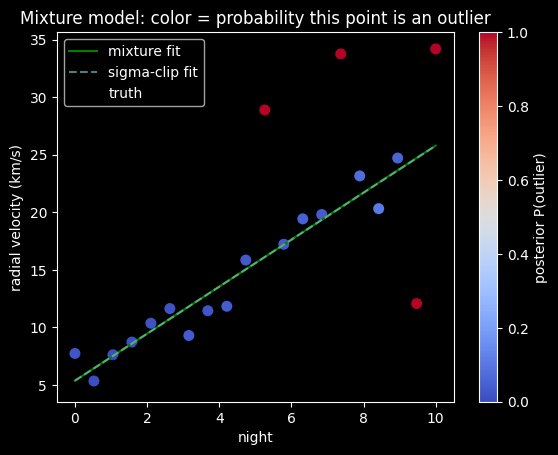

point-by-point P(outlier):
  point 14: P(outlier)=1.00  [REAL contaminant]
  point 10: P(outlier)=1.00  [REAL contaminant]
  point 18: P(outlier)=1.00  [REAL contaminant]
  point 19: P(outlier)=1.00  [REAL contaminant]
  point 16: P(outlier)=0.11  [clean]
  point 15: P(outlier)=0.08  [clean]


In [10]:
# per-point posterior probability of belonging to the "bad" population
Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x_true + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sigma)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma**2))
p_bad = bad_l / (good_l + bad_l)

plt.scatter(x_true, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0--', alpha=0.6, label='sigma-clip fit')
plt.plot(xx, 2.0 * xx + 5.0, 'k:', alpha=0.5, label='truth')
plt.xlabel('night'); plt.ylabel('radial velocity (km/s)'); plt.legend()
plt.title('Mixture model: color = probability this point is an outlier')
plt.show()

print("point-by-point P(outlier):")
for i in np.argsort(-p_bad)[:6]:
    flag = 'REAL contaminant' if i in bad else 'clean'
    print(f"  point {i}: P(outlier)={p_bad[i]:.2f}  [{flag}]")

## ...and the actual paper's mixture-model result

<img src="images/hogg2010_fig4_mixture_fit.png" alt="Hogg Bovy Lang 2010 Figure 4: marginalized posterior for the mixture model and the MAP line" width="780" style="display:block;margin:0 auto;">

<small>Figure 4 from Hogg, Bovy &amp; Lang (2010). On the left, the marginalized posterior for (m, b) under the mixture (outlier) model. On the right, the MAP line in dark grey with draws from the posterior sampling in light grey. This is the professional-literature version of the plot you just watched fit live.</small>


#### What just happened, and why it's better

No point got permanently thrown away. Every point still carries some weight in the fit, in proportion to how likely it is to be good.

The outlier fraction $P_b$ came out of the fit rather than from a threshold we picked. Compare the printed probabilities against the truly contaminated indices above: the high-probability points should mostly be the real contaminants, and the fit degrades gracefully where the classification is uncertain instead of making a hard cut it can't explain.

One thing you should be complaining about. I quoted $P_b$ with no error bar on it, in this course of all places. Hogg's Figure 4 shows what getting one actually takes, which is the full posterior. That's what the MCMC weeks are for.


## Bridge to Lab 01

Sigma-clipping is the version we can write in five minutes and defend in one sentence. It's good enough when the answer isn't close to the threshold.

The mixture model is the version that doesn't make us pre-commit to a threshold at all. It reports the outlier fraction as a real parameter, and it degrades gracefully instead of making hard cuts.

You'll implement both in Lab 01. Now you've seen why the second one earns the extra twenty minutes it costs you.


## Two more robust estimators worth knowing

Sigma-clipping and the mixture model are not the only options. Two others you will run into:

The **Theil-Sen** estimator takes the median of all the pairwise slopes $\frac{y_j - y_i}{x_j - x_i}$. It only falls apart once more than about 29% of the points are contaminated, which is its **breakdown point**. One bad point can wreck a least-squares fit, but it can't move a median of a few hundred slopes very far. It's `scipy.stats.theilslopes`.

**RANSAC** fits small random subsets over and over and keeps whichever fit the most points agree with. You see it in imaging and astrometry pipelines, image registration and WCS fitting, where the outlier fraction is large and nobody knows it ahead of time. It's `sklearn.linear_model.RANSACRegressor`.


Theil-Sen: slope=2.17 (95% CI [1.71, 2.72]), intercept=3.12
(true slope = 2.00; compare to the naive WLS and mixture-model fits above)


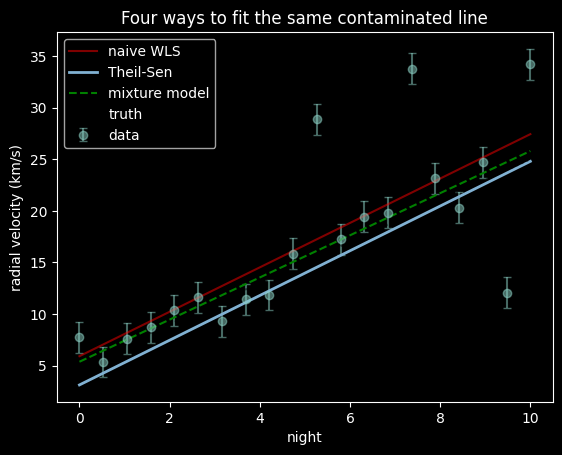

In [11]:
from scipy.stats import theilslopes

m_ts, b_ts, lo_ts, hi_ts = theilslopes(y, x_true)
print(f"Theil-Sen: slope={m_ts:.2f} (95% CI [{lo_ts:.2f}, {hi_ts:.2f}]), intercept={b_ts:.2f}")
print(f"(true slope = 2.00; compare to the naive WLS and mixture-model fits above)")

plt.errorbar(x_true, y, yerr=sigma, fmt='o', capsize=3, alpha=0.5, label='data')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', alpha=0.5, label='naive WLS')
plt.plot(xx, m_ts * xx + b_ts, 'C4-', lw=2, label='Theil-Sen')
plt.plot(xx, m_mix * xx + b_mix, 'g--', label='mixture model')
plt.plot(xx, 2.0 * xx + 5.0, 'k:', alpha=0.5, label='truth')
plt.xlabel('night'); plt.ylabel('radial velocity (km/s)'); plt.legend()
plt.title('Four ways to fit the same contaminated line')
plt.show()


## So which one do you use?

Reach for Theil-Sen or RANSAC when you want a slope and you do not want to think hard about the outliers. They are fast, they need almost no setup, and they are the right call for a quick-look fit or for a pipeline that has to run unattended on data nobody will inspect.

Reach for the mixture model when the outliers are part of the science, or when the error bar has to be defensible. It is the only one of the three that hands you an outlier fraction as a fitted parameter, with a posterior you can put an error bar on.

And notice what just happened. Nothing in the data told us which of these to use. We picked one.

That is the whole job. You do not know the truth, and your task is to write down a model.

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**Choosing the model is the hypothesis you are making, and it is the part nobody can do for you.**

</div> It is also, I hope, the reason an AI is not going to replace you.


## An error bar for a statistic with no formula

None of the median, the IQR, or the Theil-Sen slope has a clean closed-form standard error the way the least-squares slope does.

The **bootstrap** gets us one anyway, without assuming anything about the distribution. Resample the data with replacement, same size as the original. Recompute the statistic. Do it a few thousand times, and the spread of what comes back is the uncertainty.

That is the general-purpose answer to the question the rest of today asks. Is a difference real, or is it noise?


Theil-Sen slope on the real data = 2.17   (true slope = 2.00)
bootstrap 68% interval           = [1.94, 2.34]
No formula for this error bar exists. We got it by resampling.


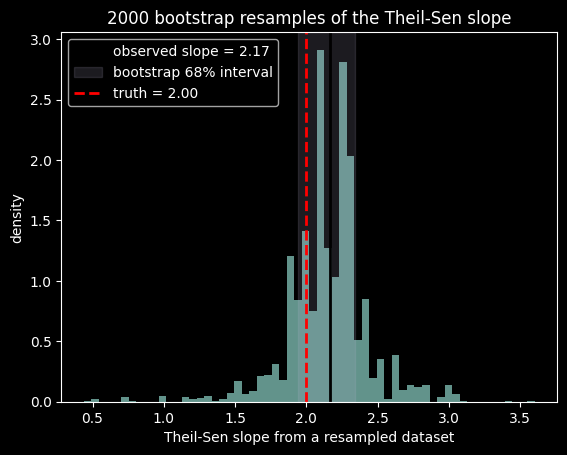

In [12]:
rng_bs = np.random.default_rng(20260901)
n_boot = 2000

# resample (x, y) PAIRS with replacement, refit Theil-Sen each time
boot_slopes = np.empty(n_boot)
for j in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    boot_slopes[j] = theilslopes(y[idx], x_true[idx])[0]

lo, hi = np.percentile(boot_slopes, [16, 84])
print(f"Theil-Sen slope on the real data = {m_ts:.2f}   (true slope = 2.00)")
print(f"bootstrap 68% interval           = [{lo:.2f}, {hi:.2f}]")
print("No formula for this error bar exists. We got it by resampling.")

plt.hist(boot_slopes, bins=60, density=True, alpha=0.7)
plt.axvline(m_ts, color='k', lw=2, label=f'observed slope = {m_ts:.2f}')
plt.axvspan(lo, hi, color='C2', alpha=0.15, label='bootstrap 68% interval')
plt.axvline(2.0, color='r', ls='--', lw=2, label='truth = 2.00')
plt.xlabel('Theil-Sen slope from a resampled dataset'); plt.ylabel('density')
plt.legend(); plt.title(f'{n_boot} bootstrap resamples of the Theil-Sen slope')
plt.show()


The interval came from resampling alone. No distributional assumption went into it anywhere, and that's what makes the bootstrap so generally useful. It gets us an error bar on a statistic whose sampling distribution we could never write down. We use the same resampling idea again in the MCMC weeks.


## Section 3: Hypothesis testing

Section 2 was about our fit, which points to trust and what the slope really is once we stop trusting all of them. The bootstrap closed it out by measuring how uncertain that slope is, with no formula available to do it.

This section is about our test, and the question barely changes shape. The bootstrap asked how far our slope would move if we had observed a different ten nights. A hypothesis test asks whether two samples that look different would still look this different if they came from the same population.

Same discipline, run on one number and then on two. What changes is the scale. The catalog we use next has 252,871 stars in it, so looking at the data and deciding stops being an option.


## Live exercise: your first package install

In your terminal, with `astr457` active:

```
conda install -c conda-forge astroml
```

Restart your kernel once it finishes.

This is the same workflow you'll use all semester whenever a lab needs a new package. Run `conda install`, confirm it landed in the right environment, then restart the kernel so the import actually picks it up.


## Meet the dataset: SDSS SEGUE Stellar Parameter Pipeline

327,260 Milky Way stars with SDSS spectra from Data Release 9. Each one has a pipeline-derived effective temperature, surface gravity, metallicity ([Fe/H]), alpha-element abundance ([alpha/Fe]), radial velocity, and proper motion.

The catalog was curated by Zeljko Ivezic, who is the first author of our textbook (Ivezic, Connolly, VanderPlas & Gray), and it's the dataset astroML's own worked examples are built around. We pull it through `astroML`, the companion package to the textbook, which you just installed.

These are real spectroscopic measurements of real stars. Every number we compute from here on is a measurement of an actual star in our own Galaxy.


252871 stars after basic quality cuts


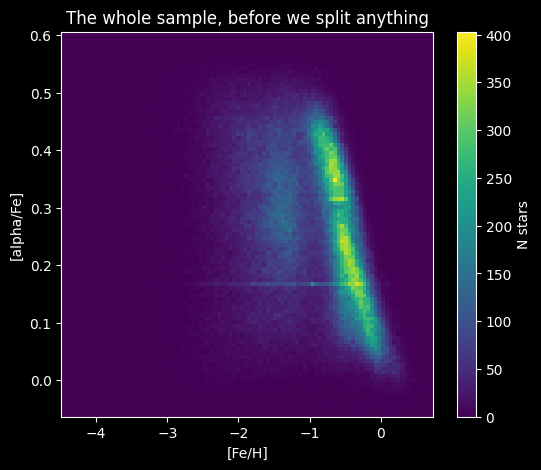

In [13]:
from astroML.datasets import fetch_sdss_sspp
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

data = fetch_sdss_sspp()
good = (data['FeHErr'] < 0.3) & (data['alphFeErr'] < 0.3) & (data['SNR'] > 20)
d = data[good]
print(f"{len(d)} stars after basic quality cuts")

plt.figure(figsize=(6, 5))
plt.hist2d(d['FeH'], d['alphFe'], bins=100, cmap='viridis')
plt.xlabel('[Fe/H]'); plt.ylabel('[alpha/Fe]')
plt.colorbar(label='N stars')
plt.title('The whole sample, before we split anything')
plt.show()

## Why this plot matters

We're looking at a direct measurement of Galactic archaeology: using the present-day chemistry of stars to reconstruct how the Milky Way disk formed.

The two streaks are two different stellar populations. One is metal-richer and lower-alpha, roughly the thin disk, younger, formed over a longer and more chemically enriched history. The other is metal-poorer and alpha-enhanced, roughly the thick disk, older, formed when the Galaxy had less time to enrich itself with iron before core-collapse supernovae seeded it with alpha elements.

[alpha/Fe] works as a rough clock because the alpha elements (O, Mg, Si, Ca, Ti) come promptly from core-collapse supernovae, while iron accumulates more slowly from Type Ia supernovae. So how alpha-enhanced a population is tells us something about how fast it formed its stars.

This is the split we'll use for today's hypothesis test. It's a real astrophysical population boundary drawn from the physics above, not an arbitrary demo cut.


## Why we have to be careful with this sample

This catalog is **not** a random sample of Milky Way stars. It's built from 10 explicit selection cuts, documented in the catalog's own header: a magnitude range, color cuts, proper-motion limits, a surface-gravity range, temperature-error cuts, and more.

The magnitude cut ($14 < r < 21$) is distance-dependent. It changes which stars we can see as a function of how far away they are, which is a classic Malmquist-type bias.

The proper-motion cut ($|\mu| < 200$ mas/yr) pre-selects on kinematics, so we cannot use this same sample to do an unbiased kinematic study without correcting for that cut first.

Any statistic we compute naively from this catalog, something like "what fraction of Milky Way stars are alpha-rich," is really answering a question about stars that pass these ten cuts.

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**That gap between the sample and the population does not announce itself in the data.**

</div>


## The question

Split the stars by alpha-element abundance. An alpha-poor sample ([alpha/Fe] < 0.1, thin-disk-like) and an alpha-rich one ([alpha/Fe] > 0.3, thick-disk-like), the same two populations we just saw in the 2D histogram.

Do their metallicities come from different distributions, or could the difference in a histogram just be sampling noise?

Our **null hypothesis** $H_0$ is that the two [Fe/H] samples are drawn from the same underlying distribution. We ask the data to talk us out of it.

Full disclosure: that cut discards every star with $0.1 < [\alpha/\mathrm{Fe}] < 0.3$. Removing the overlap sharpens the contrast by construction. It's legitimate here, since we cut on $\alpha$ and test [Fe/H], but it is a choice, and per the previous slide it belongs in your write-up.


In [14]:
alpha_poor = d[d['alphFe'] < 0.1]   # thin-disk-like
alpha_rich = d[d['alphFe'] > 0.3]   # thick-disk-like
print(f"alpha-poor: {len(alpha_poor)} stars, alpha-rich: {len(alpha_rich)} stars")

alpha-poor: 28148 stars, alpha-rich: 104427 stars


alpha-poor : median=-0.26, IQR=[-0.76, -0.07], mean=-0.54
alpha-rich : median=-1.01, IQR=[-1.53, -0.71], mean=-1.16


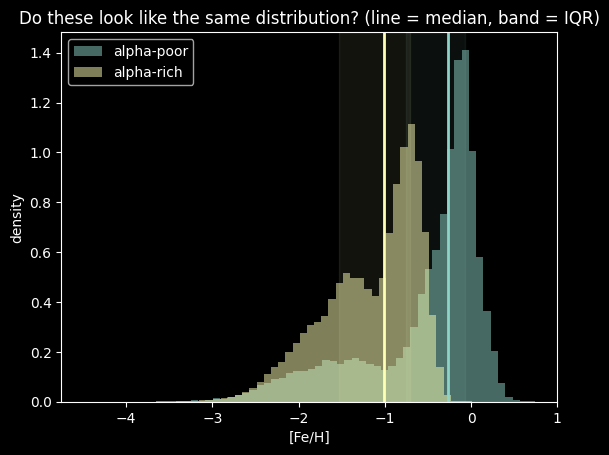

In [15]:
for sample, color, name in [(alpha_poor, 'C0', 'alpha-poor'), (alpha_rich, 'C1', 'alpha-rich')]:
    feh = sample['FeH']
    q25, q50, q75 = np.percentile(feh, [25, 50, 75])
    plt.hist(feh, bins=60, density=True, alpha=0.5, color=color, label=name)
    plt.axvline(q50, color=color, lw=2)
    plt.axvspan(q25, q75, color=color, alpha=0.08)
    print(f"{name:11s}: median={q50:+.2f}, IQR=[{q25:+.2f}, {q75:+.2f}], mean={feh.mean():+.2f}")
plt.xlabel('[Fe/H]'); plt.ylabel('density'); plt.legend()
plt.title('Do these look like the same distribution? (line = median, band = IQR)')
plt.show()

By eye they look obviously different. But "obviously different" is exactly the kind of judgment call this course keeps asking us to back up quantitatively, the same theme as the Day 1 demo and Lab 01.

The printed medians and IQR bands are already most of the story, robust summaries on real data put to work two sections after we met them. The KS test turns that comparison into a single number.


## The Kolmogorov-Smirnov two-sample test

The KS test compares the two samples' **empirical CDFs** - the data's own stand-in for the CDF we met on Day 2. Sort the sample, step up by $1/n$ at each point.

Then it asks what the largest vertical gap between them is, and how often a gap that big would happen by chance if both samples really came from the same distribution.

Let's look at the ECDFs directly before we run the test. The test statistic is just a number on this plot.


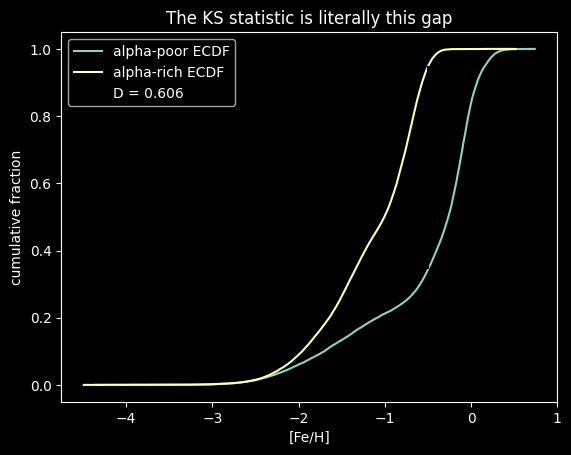

In [16]:
def ecdf(vals):
    s = np.sort(vals)
    return s, np.arange(1, len(s) + 1) / len(s)

x_poor, y_poor = ecdf(alpha_poor['FeH'])
x_rich, y_rich = ecdf(alpha_rich['FeH'])

plt.plot(x_poor, y_poor, label='alpha-poor ECDF')
plt.plot(x_rich, y_rich, label='alpha-rich ECDF')

# find and mark the largest gap, on a common grid
grid = np.linspace(min(x_poor.min(), x_rich.min()), max(x_poor.max(), x_rich.max()), 2000)
cdf_poor = np.searchsorted(x_poor, grid, side='right') / len(x_poor)
cdf_rich = np.searchsorted(x_rich, grid, side='right') / len(x_rich)
gap = np.abs(cdf_poor - cdf_rich)
i_max = np.argmax(gap)
plt.vlines(grid[i_max], cdf_rich[i_max], cdf_poor[i_max], color='k', linestyle='--',
           label=f'D = {gap[i_max]:.3f}')
plt.xlabel('[Fe/H]'); plt.ylabel('cumulative fraction'); plt.legend()
plt.title('The KS statistic is literally this gap')
plt.show()

## The KS statistic, formally

$$D = \max_x \big| F_1(x) - F_2(x) \big|$$

$F_1$ and $F_2$ are the two samples' empirical CDFs, so $D$ is just the largest vertical gap between the two curves we plotted. `scipy.stats.ks_2samp` computes $D$ and the p-value for us, and that plot is what it's doing underneath.


In [17]:
ks_stat, p_value = stats.ks_2samp(alpha_poor['FeH'], alpha_rich['FeH'])
print(f"KS statistic = {ks_stat:.4f}  (matches the gap marked above)")
print(f"p-value = {p_value:.3e}")
# p prints as 0.000e+00 - the true value underflowed machine precision (see next slide).

KS statistic = 0.6058  (matches the gap marked above)
p-value = 0.000e+00


## What does that p-value actually mean?

It is **not** the probability that the null hypothesis is true, and it is **not** the probability that the result is due to chance.

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**If the two samples really were drawn from the same distribution, the p-value is the probability of seeing a gap $D$ at least this large, purely from sampling noise.**

</div>

Same discipline as the error-bar discussion on Day 1. A p-value states what the data would look like under a specific assumption. It is not a verdict handed to us for free.

Here it's vanishingly small, so the null is not a reasonable description of what we see. The printout says $p = 0.000$, but a probability can't equal zero. The true value underflowed machine precision, so write $p < 10^{-300}$ and never $p = 0$.

Now watch what happens with much smaller samples of the exact same two real populations.


In [18]:
rng = np.random.default_rng(20260827)
n_small = 8
sub_poor = rng.choice(alpha_poor['FeH'], n_small, replace=False)
sub_rich = rng.choice(alpha_rich['FeH'], n_small, replace=False)
ks_small_sample, p_small_sample = stats.ks_2samp(sub_poor, sub_rich)
print(f"with only {n_small} stars per sample: KS={ks_small_sample:.3f}, p={p_small_sample:.3f}")
print("Same real, genuinely-different populations. This p-value says 'not significant.'")

with only 8 stars per sample: KS=0.375, p=0.660
Same real, genuinely-different populations. This p-value says 'not significant.'


With only 8 stars per sample, the same test that was overwhelmingly significant on the full sample comes back saying it can't reject the null. That's a false negative, purely from bad luck in a small draw.

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**A hypothesis test that fails to reject $H_0$ never means the two things are the same.**

</div>

It can just as easily mean our sample was too small to tell.

Sample size and test choice both belong in your write-up every time you report a p-value. It's exactly the kind of thing an AI assistant will not flag for you unprompted.


## The mirror trap: at n = 100,000, everything is significant

Our full-sample p-value underflowed to zero with 28k against 104k stars. But at that scale even a tiny, physically meaningless difference between two samples will reject the null too.

Statistical significance and scientific relevance come apart exactly when data are plentiful. That is the survey era. At LSST scale, "p < 0.05" is close to information-free.

So report the **effect size** alongside p. Here $D \approx 0.61$, meaning the two CDFs are separated by 61 percentage points at their widest, which is an enormous difference nobody would call subtle.

Small n hides real differences, as we just saw. Large n makes trivial ones scream.

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**The p-value on its own tells us neither.**

</div>


## One more trap: running the same test many times

Suppose that instead of one alpha cut we tried 20 different [Fe/H] and [alpha/Fe] binnings, looking for a significant difference somewhere.

At the standard $p<0.05$ threshold we'd expect about 1 of those 20 to look significant even if every population were drawn from the exact same distribution. That is what $p=0.05$ means.

This is the **multiple-comparisons problem** - it's what shows up when we let an AI assistant try a few different cuts and report what's significant, without telling it to correct for how many cuts it tried.

Rule of thumb for this course: if you ran more than one test, say so, and say how many. The simplest correction, Bonferroni, just demands $p < 0.05/20$ instead of $p < 0.05$.


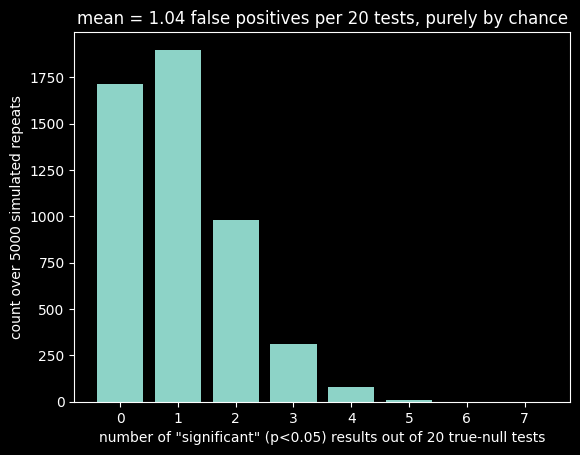

In [19]:
rng2 = np.random.default_rng(20260827)
n_trials, n_tests = 5000, 20
# simulate 5000 "nights": each night, run 20 tests where the null is TRUE
false_positives = (rng2.uniform(0, 1, size=(n_trials, n_tests)) < 0.05).sum(axis=1)

plt.hist(false_positives, bins=np.arange(-0.5, 8.5, 1), rwidth=0.8)
plt.xlabel('number of "significant" (p<0.05) results out of 20 true-null tests')
plt.ylabel('count over 5000 simulated repeats')
plt.title(f"mean = {false_positives.mean():.2f} false positives per 20 tests, purely by chance")
plt.show()

## Bridge: is a single population even Gaussian?

Every least-squares fit we did earlier today, and every one in Lab 01, implicitly assumes Gaussian residuals. A QQ-plot is the fast visual check, the same tool we opened with this morning.


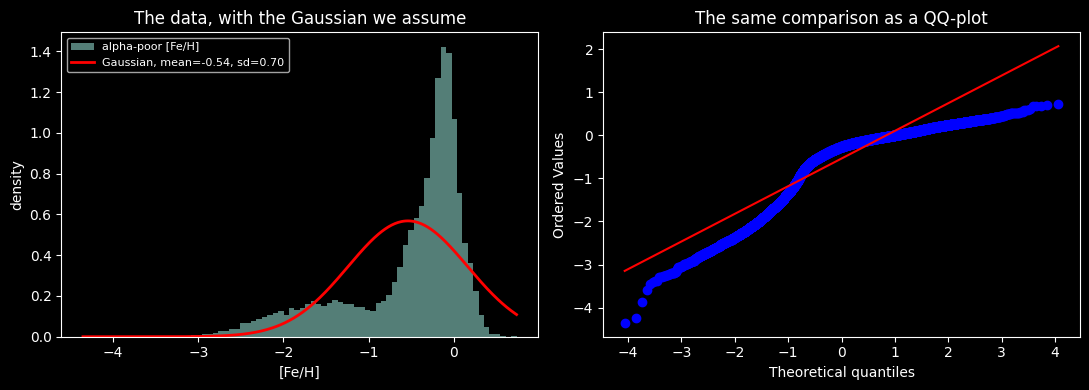

skew = -1.36   (0 for a Gaussian)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# left: the data itself, with the Gaussian we are implicitly assuming drawn over it
feh = alpha_poor['FeH']
mu, sd = feh.mean(), feh.std()
axes[0].hist(feh, bins=80, density=True, alpha=0.6, label='alpha-poor [Fe/H]')
xg = np.linspace(feh.min(), feh.max(), 400)
axes[0].plot(xg, stats.norm.pdf(xg, mu, sd), 'r-', lw=2,
             label=f'Gaussian, mean={mu:.2f}, sd={sd:.2f}')
axes[0].set_xlabel('[Fe/H]'); axes[0].set_ylabel('density'); axes[0].legend(fontsize=8)
axes[0].set_title('The data, with the Gaussian we assume')

# right: the same comparison, as a QQ-plot
stats.probplot(feh, dist='norm', plot=axes[1])
axes[1].set_title('The same comparison as a QQ-plot')
plt.tight_layout()
plt.show()

print(f"skew = {stats.skew(feh):+.2f}   (0 for a Gaussian)")


The verdict for [Fe/H] is that it is not Gaussian. The metal-poor tail peels away hard below the line, with a measured skew of about $-1.4$, so the median and IQR from Day 2 earn their keep on this very sample.

In general, if the points hug the line then Gaussian is a fine working assumption. Where they peel off, usually in the tails, is where least-squares and "3-sigma means 99.7%" start lying to us.

That's the connective tissue between today's two segments. Hypothesis tests and QQ-plots are both verification tools for assumptions we would otherwise take on faith, the same checks Day 1 introduced, now on real SDSS data instead of a ten-point demo.


## Open questions a senior undergrad could actually work on

You now have every tool these projects need: the caveats, the test, and the verdicts.

* Correct the selection function. Forward-model the catalog's ten selection cuts through a Milky Way stellar population model and ask how the [Fe/H] and [alpha/Fe] distribution you'd infer changes once selection is accounted for. Well-posed and tractable.
* Cross-check against modern astrometry. This is DR9-era SEGUE data from around 2012, and Gaia now gives parallaxes and proper motions for the same stars. Do the thin and thick disk populations hold up once you add real distances and orbits, instead of inferring membership from chemistry alone?
* Chemistry against kinematics. This catalog already has radial velocities and proper motions in it, unused in today's demo. Do chemically-defined populations and kinematically-defined ones agree about which stars belong to which disk component? They don't always, and that disagreement is an active research question.
* Age-abundance relations. This catalog alone has no ages, but cross-matching against surveys that do, like asteroseismology or isochrone fitting, lets you test whether alpha-rich really always means old. That one is genuinely open right now.


## Wrapping up

The question we started with on Day 2 still stands. How do we verify that our data, our fit, and our test are telling us the truth?

Robust statistics gave us four answers today: clip at k sigma, measure sigma from the data with MAD when we don't trust the one we were given, model the outliers explicitly with a mixture, or use an estimator like Theil-Sen that doesn't care much about them. QQ-plots tell us whether Gaussian was ever a fair assumption in the first place. The bootstrap gets us an error bar on almost anything.

And the KS test tells us whether a difference is real, with two traps on either side of it. Too little data hides real differences; too much data makes trivial ones significant.

Lab 01 posts Thu Sep 3 and is due Wed Sep 9 at Noon, fork then PR as always. It asks you to build both the k-sigma clipping and the mixture model yourself, on your own dataset.

Today's in-class exercises are optional practice and are not collected. Read `help/astro_conventions.md` before you start Lab 01.
